# Notebook 1 — Does the released Metis model really erase old facts?

**Goal:** check, on the real released model `IAAR-Shanghai/Metis-4B`, whether its memory
can erase an old fact when the fact changes ("Alice lives in Dhaka" → "Alice moved to Tokyo").

**We do NOT change Metis.** We only *watch* what its memory does.

**Kaggle settings before you start**
1. Accelerator: **GPU T4 x2** (or any GPU with 16 GB).
2. Internet: **On**.
3. Add-ons → Secrets: add your Hugging Face token with the name **HF_TOKEN**.
4. Run the cells **in order, from top to bottom**, in a fresh session.

**Two tests**
* **Test 1 (mechanism):** how much of the old memory does the update sentence erase?
  We compare Metis *as released* with the same model if its keys had *normal size*.
* **Test 2 (behaviour):** what does the model actually answer after an update?

In [1]:
# CELL 1 -- Install the exact Transformers version Metis was saved with
!pip install -q "transformers==5.4.0" accelerate

import transformers
from transformers.models.auto.configuration_auto import CONFIG_MAPPING_NAMES

print("Transformers version:", transformers.__version__)
print("Loaded from        :", transformers.__file__)

qwen_models = []
for model_type in CONFIG_MAPPING_NAMES:
    if model_type.startswith("qwen"):
        qwen_models.append(model_type)
print("Qwen models this version knows:", qwen_models)

if "qwen3_5" in qwen_models:
    print("\nOK: qwen3_5 is supported. Continue with Cell 2.")
else:
    print("\nPROBLEM: qwen3_5 is NOT supported. Share this output.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 92.2 MB/s eta 0:00:00:00:010:01
Transformers version: 5.4.0
Loaded from        : /usr/local/lib/python3.12/dist-packages/transformers/__init__.py
Qwen models this version knows: ['qwen2', 'qwen2_5_omni', 'qwen2_5_vl', 'qwen2_5_vl_text', 'qwen2_audio', 'qwen2_audio_encoder', 'qwen2_moe', 'qwen2_vl', 'qwen2_vl_text', 'qwen3', 'qwen3_5', 'qwen3_5_moe', 'qwen3_5_moe_text', 'qwen3_5_text', 'qwen3_moe', 'qwen3_next', 'qwen3_omni_moe', 'qwen3_vl', 'qwen3_vl_moe', 'qwen3_vl_moe_text', 'qwen3_vl_text']

OK: qwen3_5 is supported. Continue with Cell 2.


In [3]:
# CELL 2 -- HuggingFace login
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

try:
    user_secrets = UserSecretsClient()
    secret_value_0 = user_secrets.get_secret("HF_TOKEN")
    login(secret_value_0)
    print("HuggingFace login done")
except Exception as error:
    print("Login skipped (the Metis model is public, so this is usually fine).")
    print("Reason:", error)

HuggingFace login done


In [4]:
# CELL 3 -- Imports + GPU + settings
import os
import json
import time
import gc

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

OUTPUT_DIR = "/kaggle/working/metis_reproduce"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"PyTorch : {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"GPUs    : {torch.cuda.device_count()}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("GPU     : none (this will be very slow)")
print(f"Output  : {OUTPUT_DIR}")

CONFIG = {
    # The released model we are checking
    "model_id"        : "IAAR-Shanghai/Metis-4B",

    # Answer length when we ask a question
    "max_new_tokens"  : 20,

    # These two prompts are copied from the Metis paper (Appendix F.2.2),
    # so we talk to the model the same way the authors did.
    "commit_prefix"   : "Conversation memory segment.\n"
                        "Commit the following dialogue segment to memory for later question answering.\n",
    "query_prefix"    : "Answer from the learned memory state produced during the information phase.\n"
                        "Give the shortest factual answer you can. Do not explain.\n"
                        "Question: ",
    "query_suffix"    : "\nShort answer:",

    # Output files
    "mechanism_file"  : f"{OUTPUT_DIR}/test1_mechanism.csv",
    "behaviour_file"  : f"{OUTPUT_DIR}/test2_behaviour.csv",
    "summary_file"    : f"{OUTPUT_DIR}/summary.json",
}
print("Settings ready.")

PyTorch : 2.10.0+cu128
GPU     : Tesla T4
GPUs    : 2
VRAM    : 15.6 GB
Output  : /kaggle/working/metis_reproduce
Settings ready.


In [5]:
# CELL 4 -- Tokenizer + small helper functions to talk to Metis
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_id"], trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


def make_chat_text(user_message, add_generation_prompt):
    """Turn one user message into the chat format the model expects."""
    messages = [{"role": "user", "content": user_message}]
    try:
        # Qwen3.5 models can "think" before answering. We switch that off.
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=add_generation_prompt,
            enable_thinking=False,
        )
    except TypeError:
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=add_generation_prompt,
        )
    return text


def get_model_device(model):
    """Find out if the model lives on the GPU or the CPU."""
    first_parameter = next(model.parameters())
    return first_parameter.device


def commit_to_memory(model, sentence):
    """Write one sentence into Metis's native memory (no answer is generated)."""
    text = make_chat_text(CONFIG["commit_prefix"] + sentence, add_generation_prompt=False)
    input_ids = tokenizer.encode(text, add_special_tokens=False, return_tensors="pt")
    input_ids = input_ids.to(get_model_device(model))
    attention_mask = torch.ones_like(input_ids)
    with torch.no_grad():
        model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            commit_memory=True,      # <- this tells Metis to store the sentence
            use_cache=False,
            logits_to_keep=1,
        )


def ask(model, question):
    """Ask a question. The model only sees the question + its memory, not the old sentences."""
    text = make_chat_text(CONFIG["query_prefix"] + question + CONFIG["query_suffix"],
                          add_generation_prompt=True)
    input_ids = tokenizer.encode(text, add_special_tokens=False, return_tensors="pt")
    input_ids = input_ids.to(get_model_device(model))
    attention_mask = torch.ones_like(input_ids)
    with torch.no_grad():
        output = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=CONFIG["max_new_tokens"],
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    new_tokens = output[0, input_ids.shape[1]:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return answer.strip()


print("Helper functions ready.")

config.json: 0.00B [00:00, ?B/s]

configuration_metis.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/IAAR-Shanghai/Metis-4B:
- configuration_metis.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/20.0M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Helper functions ready.


In [6]:
# CELL 5 -- Load Metis-4B (tries the best number format for your GPU, with safe fallbacks)
# T4 / P100 GPUs do not natively support bfloat16, so we try a few options one by one
# and keep the first one that loads AND gives sensible (finite) numbers.


def load_metis(dtype, device):
    print(f"\nTrying to load Metis with dtype={dtype} on {device} ...")
    start_time = time.time()
    try:
        model = AutoModelForCausalLM.from_pretrained(CONFIG["model_id"],  trust_remote_code=True, dtype=dtype)
    except TypeError:
        model = AutoModelForCausalLM.from_pretrained(CONFIG["model_id"], trust_remote_code=True, torch_dtype=dtype)
    model = model.to(device)
    model.eval()
    print(f"Loaded in {time.time() - start_time:.0f} seconds.")
    return model


def health_check(model):
    """Store one sentence, ask about it, and make sure nothing is NaN/inf."""
    model.reset()
    commit_to_memory(model, "My favorite number is 7.")
    text = make_chat_text("Hello", add_generation_prompt=True)
    input_ids = tokenizer.encode(text, add_special_tokens=False, return_tensors="pt").to(get_model_device(model))
    with torch.no_grad():
        logits = model(input_ids=input_ids, use_cache=False).logits
    numbers_are_fine = bool(torch.isfinite(logits.float()).all().item())
    answer = ask(model, "What is my favorite number?")
    model.reset()
    print(f"  Numbers finite: {numbers_are_fine} | Test answer: {answer!r}")
    return numbers_are_fine and len(answer) > 0


attempts = []
if torch.cuda.is_available():
    major_version, minor_version = torch.cuda.get_device_capability(0)
    attempts.append((torch.bfloat16, "cuda"))
    attempts.append((torch.float16, "cuda"))
    if major_version < 8:
        attempts.append((torch.float32, "cpu"))   # last resort: slow but safe
else:
    attempts.append((torch.float32, "cpu"))

model = None
for dtype, device in attempts:
    try:
        candidate = load_metis(dtype, device)
        if health_check(candidate):
            model = candidate
            MODEL_DTYPE = dtype
            break
        print("  Health check failed with this setting, trying the next one.")
        del candidate
    except Exception as error:
        print("  Could not use this setting. Reason:", str(error)[:300])
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if model is None:
    raise RuntimeError("Metis could not be loaded. Copy the messages above and share them.")
print(f"\nMetis-4B is ready (dtype = {MODEL_DTYPE}, device = {get_model_device(model)}).")


Trying to load Metis with dtype=torch.bfloat16 on cuda ...


modeling_metis.py: 0.00B [00:00, ?B/s]

metis_local_memory.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/IAAR-Shanghai/Metis-4B:
- metis_local_memory.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


utils.py: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/507 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/157 [00:00<?, ?B/s]

Loaded in 66 seconds.


The remote code model you are currently using seems to expect `cache_position`. This arg has been removed from the Transformers library, and will stop being created in `generate` even for remote code models in a future release. Please open a PR on the remote code hub repo to remove any usage of `cache_position`.


  Numbers finite: True | Test answer: 'The answer is 7.'

Metis-4B is ready (dtype = torch.bfloat16, device = cuda:0).


In [7]:
# CELL 6 -- Find the memory layers and read the memory settings from the real checkpoint
memory_blocks = []
for layer_index in range(len(model.model.metis_blocks)):
    block = model.model.metis_blocks[layer_index]
    if block.local_memory is not None and block.hyper_memory is not None:
        memory_blocks.append((layer_index, block))

print("Number of layers that have a memory:", len(memory_blocks))
print("Their layer numbers:", [layer_index for layer_index, block in memory_blocks])

first_hyper_memory = memory_blocks[0][1].hyper_memory
print("\nMemory update class :", type(first_hyper_memory).__name__)
print("Memory size (kv_dim):", first_hyper_memory.kv_dim)
print("update_ratio        :", first_hyper_memory.update_ratio)
print("\nmemory_configs from the checkpoint's config.json:")
for key, value in model.config.memory_configs.items():
    print(f"  {key}: {value}")

HAS_GATED_DELTA = hasattr(type(first_hyper_memory), "_apply_gated_delta_rule_update")
print("\nUses the gated-delta update (the one the paper describes):", HAS_GATED_DELTA)
if not HAS_GATED_DELTA:
    print("!! This checkpoint uses a different update. Test 1 below cannot run. Share this output.")

Number of layers that have a memory: 8
Their layer numbers: [3, 7, 11, 15, 19, 23, 27, 31]

Memory update class : StraightThroughAlphaTopPGatedDeltaRuleMetisHyperMemory
Memory size (kv_dim): 1024
update_ratio        : 0.9

memory_configs from the checkpoint's config.json:
  alpha_max_fraction: 0.0
  alpha_max_tokens: 0
  alpha_min_tokens: 1
  alpha_top_p: 0.9
  commit_hidden_offset: 0
  forget_ratio: 1.0
  gated_delta_alpha_init: 1.0
  gated_delta_beta_init: 1.0
  gumbel_topk_noise: True
  mem_norm_init: 1.0
  metis_block_type: NormedReweightLearnedQueryMetisBlock
  metis_hyper_memory_type: StraightThroughAlphaTopPGatedDeltaRuleMetisHyperMemory
  metis_local_memory_type: NormalizedDeltaNetMetisLocalMemory
  metis_reweight_gamma: 0.9
  pool_temperature: 1.0
  qk_kernel_type: elu_plus_one
  stride_interval: 8
  uniform_num_selected: 16
  update_ratio: 0.9

Uses the gated-delta update (the one the paper describes): True


In [8]:
# CELL 7 -- Install a "recorder" that WATCHES each memory write (it does not change anything)
#
# Metis's update (from its own code) is:
#     new_memory = alpha * (old_memory - E @ old_memory) + (what is added)
#     E = sum over tokens of  beta_i * k_i k_i^T          <- the "eraser"
# We measure two things for every write:
#   1) "old memory erased (%)": how big E @ old_memory is, compared with old_memory.
#   2) The same number if the keys had NORMAL size (length 1) instead of being
#      divided by sqrt(kv_dim) like the released code does.
# We also record "fade (%)" = (1 - alpha) * 100, the global fade that hits ALL facts.

RECORDS = []
CURRENT_WRITE_LABEL = {"text": ""}
LAYER_NUMBER_OF_MODULE = {}
for layer_index, block in memory_blocks:
    LAYER_NUMBER_OF_MODULE[id(block.hyper_memory)] = layer_index

HyperMemoryClass = type(first_hyper_memory)
ORIGINAL_UPDATE_FUNCTION = HyperMemoryClass._apply_gated_delta_rule_update


def recording_update(self, h_normed, weights, local_memory):
    # Step 1: copy the memory BEFORE this write
    old_state = local_memory.state
    if old_state is not None:
        old_state = old_state.detach().float().clone()

    # Step 2: let Metis do its normal update (we do not touch it)
    ORIGINAL_UPDATE_FUNCTION(self, h_normed, weights, local_memory)

    # Step 3: recompute the same pieces Metis used, in float32, and measure them
    with torch.no_grad():
        raw_keys = self.W_k(h_normed).float()                       # (1, tokens, D)
        normal_size_keys = F.normalize(raw_keys, dim=-1)            # every key has length 1
        released_keys = normal_size_keys / (self.kv_dim ** 0.5)     # what the released code uses

        token_weights = weights.float()                             # importance of each token
        beta_gate = torch.sigmoid(self.gated_delta_beta(h_normed).float().squeeze(-1))
        alpha_gate = torch.sigmoid(self.gated_delta_alpha(h_normed).float().squeeze(-1))
        beta = token_weights * self.update_ratio * beta_gate        # write/erase strength per token
        alpha = (token_weights * alpha_gate).sum() / token_weights.sum().clamp(min=1e-6)

        # Build the eraser matrix E for both key sizes
        eraser_released = (released_keys[0] * beta[0].unsqueeze(-1)).T @ released_keys[0]
        eraser_normal = (normal_size_keys[0] * beta[0].unsqueeze(-1)).T @ normal_size_keys[0]

        record = {
            "write"                      : CURRENT_WRITE_LABEL["text"],
            "layer"                      : LAYER_NUMBER_OF_MODULE.get(id(self), -1),
            "key_length_squared_released": float((released_keys[0] ** 2).sum(dim=-1).mean()),
            "total_write_strength"       : float(beta.sum()),
            "fade_percent"               : float((1.0 - alpha) * 100),
            "max_erase_percent_released" : float(torch.linalg.eigvalsh(eraser_released).max() * 100),
            "max_erase_percent_normal"   : float(torch.linalg.eigvalsh(eraser_normal).max() * 100),
            "old_erased_percent_released": float("nan"),
            "old_erased_percent_normal"  : float("nan"),
        }
        if old_state is not None and float(old_state.norm()) > 0:
            old_memory = old_state[0]
            erased_released = eraser_released @ old_memory
            erased_normal = eraser_normal @ old_memory
            record["old_erased_percent_released"] = float(erased_released.norm() / old_memory.norm() * 100)
            record["old_erased_percent_normal"] = float(erased_normal.norm() / old_memory.norm() * 100)
    RECORDS.append(record)


if HAS_GATED_DELTA:
    HyperMemoryClass._apply_gated_delta_rule_update = recording_update
    print("Recorder installed. Metis behaves exactly the same; we only take measurements.")

Recorder installed. Metis behaves exactly the same; we only take measurements.


In [9]:
# CELL 8 -- TEST 1 (mechanism): how much of "Dhaka" does "moved to Tokyo" erase?
#
# For each pair we run two separate sessions:
#   UPDATE : "X lives in CITY1."  ->  "X moved to CITY2."
#   CONTROL: "X lives in CITY1."  ->  an unrelated sentence
# If the eraser works, the UPDATE should erase clearly MORE than the CONTROL.

TEST1_PAIRS = [
    ("Alice",  "Dhaka",   "Tokyo",   "The weather was sunny yesterday."),
    ("Rahim",  "Paris",   "Cairo",   "Bob bought a new bicycle."),
    ("Maria",  "London",  "Seoul",   "The museum opens at nine."),
    ("Kenji",  "Berlin",  "Lima",    "I had tea this morning."),
    ("Fatima", "Madrid",  "Oslo",    "The train was a bit late."),
    ("Omar",   "Sydney",  "Vienna",  "The cat slept on the sofa."),
]


def run_two_writes(first_sentence, second_sentence):
    """Fresh memory -> write sentence 1 -> write sentence 2. Returns the records of write 2."""
    model.reset()
    RECORDS.clear()
    CURRENT_WRITE_LABEL["text"] = "first"
    commit_to_memory(model, first_sentence)
    CURRENT_WRITE_LABEL["text"] = "second"
    commit_to_memory(model, second_sentence)
    second_write_records = []
    for record in RECORDS:
        if record["write"] == "second":
            second_write_records.append(dict(record))
    return second_write_records


test1_rows = []
if HAS_GATED_DELTA:
    for name, old_city, new_city, unrelated_sentence in TEST1_PAIRS:
        first_sentence = f"{name} lives in {old_city}."
        for scenario, second_sentence in [("UPDATE", f"{name} moved to {new_city}."),
                                          ("CONTROL", unrelated_sentence)]:
            for record in run_two_writes(first_sentence, second_sentence):
                record["scenario"] = scenario
                record["person"] = name
                test1_rows.append(record)
    model.reset()

test1_table = pd.DataFrame(test1_rows)
test1_table.to_csv(CONFIG["mechanism_file"], index=False)

summary_columns = ["old_erased_percent_released", "old_erased_percent_normal",
                   "max_erase_percent_released", "max_erase_percent_normal",
                   "fade_percent", "key_length_squared_released"]
test1_summary = test1_table.groupby("scenario")[summary_columns].mean().round(4)
print("TEST 1 — averages over all memory layers and all 6 people\n")
print(test1_summary.T.to_string())
print("\nHow to read this:")
print("  old_erased_percent_released : % of the old memory the 2nd sentence erased in the REAL model")
print("  old_erased_percent_normal   : same, if the keys had normal size (length 1)")
print("  fade_percent                : global fade applied to ALL facts at this write")
print(f"  key_length_squared_released : should be 1/kv_dim = {1 / first_hyper_memory.kv_dim:.6f}")

TEST 1 — averages over all memory layers and all 6 people

scenario                     CONTROL   UPDATE
old_erased_percent_released   0.0024   0.0025
old_erased_percent_normal     2.5012   2.5781
max_erase_percent_released    0.0040   0.0040
max_erase_percent_normal      4.0831   4.1108
fade_percent                 41.4566  40.2918
key_length_squared_released   0.0010   0.0010

How to read this:
  old_erased_percent_released : % of the old memory the 2nd sentence erased in the REAL model
  old_erased_percent_normal   : same, if the keys had normal size (length 1)
  fade_percent                : global fade applied to ALL facts at this write
  key_length_squared_released : should be 1/kv_dim = 0.000977


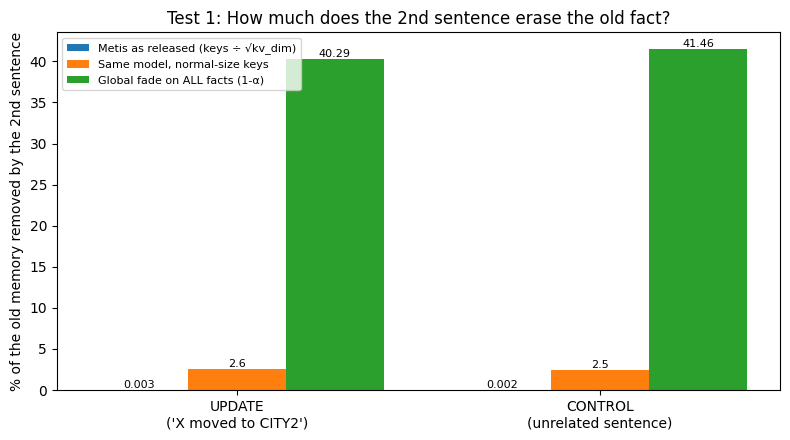

In [10]:
# CELL 9 -- Graph for Test 1
if len(test1_rows) > 0:
    scenarios = ["UPDATE", "CONTROL"]
    released_means = []
    normal_means = []
    fade_means = []
    for scenario in scenarios:
        rows_of_scenario = test1_table[test1_table["scenario"] == scenario]
        released_means.append(rows_of_scenario["old_erased_percent_released"].mean())
        normal_means.append(rows_of_scenario["old_erased_percent_normal"].mean())
        fade_means.append(rows_of_scenario["fade_percent"].mean())

    positions = np.arange(len(scenarios))
    bar_width = 0.27
    figure, axis = plt.subplots(figsize=(8, 4.5))
    axis.bar(positions - bar_width, released_means, bar_width, label="Metis as released (keys ÷ √kv_dim)")
    axis.bar(positions, normal_means, bar_width, label="Same model, normal-size keys")
    axis.bar(positions + bar_width, fade_means, bar_width, label="Global fade on ALL facts (1-α)")
    for index in range(len(scenarios)):
        axis.text(positions[index] - bar_width, released_means[index], f"{released_means[index]:.3f}",
                  ha="center", va="bottom", fontsize=8)
        axis.text(positions[index], normal_means[index], f"{normal_means[index]:.1f}",
                  ha="center", va="bottom", fontsize=8)
        axis.text(positions[index] + bar_width, fade_means[index], f"{fade_means[index]:.2f}",
                  ha="center", va="bottom", fontsize=8)
    axis.set_xticks(positions)
    axis.set_xticklabels(["UPDATE\n('X moved to CITY2')", "CONTROL\n(unrelated sentence)"])
    axis.set_ylabel("% of the old memory removed by the 2nd sentence")
    axis.set_title("Test 1: How much does the 2nd sentence erase the old fact?")
    axis.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/test1_mechanism.png", dpi=150)
    plt.show()

In [11]:
# CELL 10 -- TEST 2 (behaviour): what does the model actually answer?
#
# For each person we run three short sessions:
#   A) BASELINE : "X lives in CITY1."                        -> ask the city  (memory works?)
#   B) UPDATE   : "X lives in CITY1." -> "X moved to CITY2." -> ask the city  (new, old, both?)
#   C) OTHER    : "X lives in CITY1." -> "X works as a JOB." -> "X moved to CITY2." -> ask the job
#                                                            (does the update hurt other facts?)

TEST2_PEOPLE = [
    ("Alice", "Dhaka", "Tokyo", "nurse"),      ("Rahim", "Paris", "Cairo", "teacher"),
    ("Maria", "London", "Seoul", "pilot"),     ("Kenji", "Berlin", "Lima", "chef"),
    ("Fatima", "Madrid", "Oslo", "lawyer"),    ("Omar", "Sydney", "Vienna", "farmer"),
    ("Lena", "Rome", "Nairobi", "dentist"),    ("Arjun", "Toronto", "Lisbon", "architect"),
    ("Sofia", "Chicago", "Bangkok", "banker"), ("Yusuf", "Mumbai", "Dubai", "plumber"),
    ("Hana", "Seoul", "Madrid", "journalist"), ("Diego", "Cairo", "Berlin", "engineer"),
    ("Nora", "Oslo", "Chicago", "painter"),    ("Tariq", "Lima", "Paris", "librarian"),
    ("Emma", "Vienna", "Mumbai", "baker"),     ("Ravi", "Nairobi", "London", "pharmacist"),
    ("Chloe", "Dubai", "Sydney", "electrician"), ("Ahmed", "Lisbon", "Rome", "photographer"),
    ("Mei", "Bangkok", "Toronto", "firefighter"), ("Lucas", "Tokyo", "Dhaka", "doctor"),
]


def contains(answer, word):
    return word.lower() in answer.lower()


test2_rows = []
for name, old_city, new_city, job in TEST2_PEOPLE:
    # A) baseline
    model.reset()
    commit_to_memory(model, f"{name} lives in {old_city}.")
    baseline_answer = ask(model, f"Where does {name} live?")

    # B) update
    model.reset()
    commit_to_memory(model, f"{name} lives in {old_city}.")
    commit_to_memory(model, f"{name} moved to {new_city}.")
    update_answer = ask(model, f"Where does {name} live?")

    # C) other fact after an update
    model.reset()
    commit_to_memory(model, f"{name} lives in {old_city}.")
    commit_to_memory(model, f"{name} works as a {job}.")
    commit_to_memory(model, f"{name} moved to {new_city}.")
    job_answer = ask(model, f"What is {name}'s job?")

    has_new = contains(update_answer, new_city)
    has_old = contains(update_answer, old_city)
    if has_new and not has_old:
        update_outcome = "new only (correct)"
    elif has_old and not has_new:
        update_outcome = "old only (stale)"
    elif has_new and has_old:
        update_outcome = "both (mixed)"
    else:
        update_outcome = "neither"

    test2_rows.append({
        "person": name, "old_city": old_city, "new_city": new_city, "job": job,
        "baseline_answer": baseline_answer,
        "baseline_correct": contains(baseline_answer, old_city),
        "update_answer": update_answer,
        "update_outcome": update_outcome,
        "job_answer": job_answer,
        "job_kept": contains(job_answer, job),
    })
    print(f"{name:7s} | baseline: {baseline_answer[:25]:25s} | after update: {update_answer[:25]:25s} | job: {job_answer[:20]}")
model.reset()

test2_table = pd.DataFrame(test2_rows)
test2_table.to_csv(CONFIG["behaviour_file"], index=False)

Alice   | baseline: Alice lives in Dhaka.     | after update: Tokyo.                    | job: Alice is a nurse.
Rahim   | baseline: Rahim lives in Paris.     | after update: Rahim lives in Cairo.     | job: Rahim is a teacher.
Maria   | baseline: London.                   | after update: London.                   | job: Maria is a teacher.
Kenji   | baseline: Kenji lives in Berlin.    | after update: Kenji lives in Berlin.    | job: Kenji is a chef.
Fatima  | baseline: Fatima lives in Madrid.   | after update: Fatima lives in Madrid.   | job: Fatima is a lawyer.
Omar    | baseline: Sydney.                   | after update: Sydney.                   | job: Omar is a teacher.
Lena    | baseline: Lena lives in Rome.       | after update: Lena lives in Rome.       | job: Lena is a doctor.
Arjun   | baseline: Arjun lives in Toronto.   | after update: Arjun lives in Toronto.   | job: Arjun is an architec
Sofia   | baseline: Sofia lives in Chicago.   | after update: Sofia lives in Chicago.  

                               Measurement  Percent of people
            Remembers the city (no update)              100.0
          After update: new only (correct)               20.0
            After update: old only (stale)               80.0
                After update: both (mixed)                0.0
                     After update: neither                0.0
Job still remembered after the city update               60.0


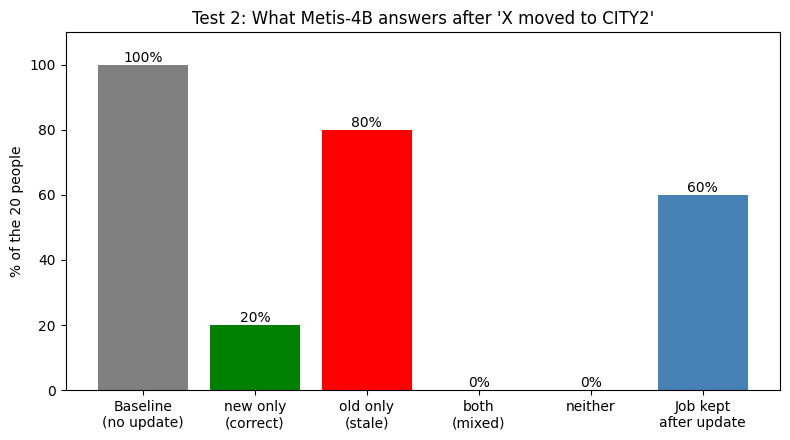

In [12]:
# CELL 11 -- Test 2 results: table + graph
number_of_people = len(test2_table)
baseline_rate = test2_table["baseline_correct"].mean() * 100
job_kept_rate = test2_table["job_kept"].mean() * 100
outcome_counts = test2_table["update_outcome"].value_counts()

outcome_names = ["new only (correct)", "old only (stale)", "both (mixed)", "neither"]
outcome_percents = []
for outcome_name in outcome_names:
    count = int(outcome_counts.get(outcome_name, 0))
    outcome_percents.append(count / number_of_people * 100)

results_table = pd.DataFrame({
    "Measurement": ["Remembers the city (no update)"] +
                   [f"After update: {name}" for name in outcome_names] +
                   ["Job still remembered after the city update"],
    "Percent of people": [baseline_rate] + outcome_percents + [job_kept_rate],
})
results_table["Percent of people"] = results_table["Percent of people"].round(1)
print(results_table.to_string(index=False))

figure, axis = plt.subplots(figsize=(8, 4.5))
bar_labels = ["Baseline\n(no update)"] + [name.replace(" (", "\n(") for name in outcome_names] + ["Job kept\nafter update"]
bar_values = [baseline_rate] + outcome_percents + [job_kept_rate]
bars = axis.bar(bar_labels, bar_values, color=["gray", "green", "red", "orange", "lightgray", "steelblue"])
for bar, value in zip(bars, bar_values):
    axis.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.0f}%", ha="center", va="bottom")
axis.set_ylim(0, 110)
axis.set_ylabel("% of the 20 people")
axis.set_title("Test 2: What Metis-4B answers after 'X moved to CITY2'")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/test2_behaviour.png", dpi=150)
plt.show()

In [13]:
# CELL 12 -- Summary and plain-English verdict
summary = {"model": CONFIG["model_id"], "dtype": str(MODEL_DTYPE)}

if len(test1_rows) > 0:
    update_rows = test1_table[test1_table["scenario"] == "UPDATE"]
    control_rows = test1_table[test1_table["scenario"] == "CONTROL"]
    summary["update_erased_percent_released"] = float(update_rows["old_erased_percent_released"].mean())
    summary["update_erased_percent_normal_keys"] = float(update_rows["old_erased_percent_normal"].mean())
    summary["control_erased_percent_released"] = float(control_rows["old_erased_percent_released"].mean())
    summary["control_erased_percent_normal_keys"] = float(control_rows["old_erased_percent_normal"].mean())
    summary["average_fade_percent"] = float(test1_table["fade_percent"].mean())
summary["baseline_correct_percent"] = float(baseline_rate)
summary["update_outcomes_percent"] = dict(zip(outcome_names, outcome_percents))
summary["job_kept_percent"] = float(job_kept_rate)

with open(CONFIG["summary_file"], "w") as file:
    json.dump(summary, file, indent=2)

print("=" * 70)
print("VERDICT")
print("=" * 70)
if len(test1_rows) > 0:
    erased_real = summary["update_erased_percent_released"]
    erased_normal = summary["update_erased_percent_normal_keys"]
    print(f"Update sentence erased {erased_real:.3f}% of the old memory in the REAL model.")
    print(f"With normal-size keys, the same write would erase {erased_normal:.1f}%.")
    print(f"Global fade on every write: {summary['average_fade_percent']:.2f}% (this hits ALL facts).")
    if erased_real < 1.0 and erased_normal > 5 * max(erased_real, 1e-6):
        print("\n=> MECHANISM CONFIRMED: in the released model the eraser is effectively OFF.")
        print("   New facts are written ON TOP of old ones instead of replacing them.")
    else:
        print("\n=> Mechanism NOT confirmed: the released model does erase noticeably. Share these numbers.")

correct_after_update = outcome_percents[0]
print(f"\nBehaviour: {correct_after_update:.0f}% of people gave ONLY the new city after an update.")
if baseline_rate < 70:
    print("   Note: baseline recall is low, so the model struggles to remember even without updates.")
if correct_after_update >= 80:
    print("   The model still answers updates well here. It compensates (e.g. recency or fade),")
    print("   so the important question moves to Notebook 2: what does that compensation COST")
    print("   for other facts and for long conversations?")
else:
    print("   Updates are unreliable in the real model: the dormant eraser shows up in behaviour.")
print(f"Other fact (job) kept after the update: {job_kept_rate:.0f}%")
print("\nSaved:", CONFIG["mechanism_file"], CONFIG["behaviour_file"], CONFIG["summary_file"])

VERDICT
Update sentence erased 0.003% of the old memory in the REAL model.
With normal-size keys, the same write would erase 2.6%.
Global fade on every write: 40.87% (this hits ALL facts).

=> MECHANISM CONFIRMED: in the released model the eraser is effectively OFF.
   New facts are written ON TOP of old ones instead of replacing them.

Behaviour: 20% of people gave ONLY the new city after an update.
   Updates are unreliable in the real model: the dormant eraser shows up in behaviour.
Other fact (job) kept after the update: 60%

Saved: /kaggle/working/metis_reproduce/test1_mechanism.csv /kaggle/working/metis_reproduce/test2_behaviour.csv /kaggle/working/metis_reproduce/summary.json


In [14]:
# CELL 13 -- (Optional) Remove the recorder so Metis is back to its original code
if HAS_GATED_DELTA:
    HyperMemoryClass._apply_gated_delta_rule_update = ORIGINAL_UPDATE_FUNCTION
    print("Recorder removed.")
print("Done.")

Recorder removed.
Done.
